In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/Consulting_survey_DataSet (3).csv'
df = pd.read_csv(file_path)

In [ ]:
df.columns = [
    'timestamp',
    'current_consulting_firm',
    'current_firm',
    'current_practice',
    'current_title',
    'current_country',
    'current_compensation_usd',
    'estimated_bonus_usd_2021',
    'expected_total_compensation',
    'weekly_hours',
    'offer_received',
    'offer_from_consulting_firm',
    'highest_offer_firm',
    'offer_practice',
    'offered_title',
    'offer_country',
    'highest_offer_compensation_usd',
    'highest_offer_bonus_usd',
    'accepted_offer'
]

In [ ]:
df

,timestamp,current_consulting_firm,current_firm,current_practice,current_title,current_country,current_compensation_usd,estimated_bonus_usd_2021,expected_total_compensation,weekly_hours,offer_received,offer_from_consulting_firm,highest_offer_firm,offer_practice,offered_title,offer_country,highest_offer_compensation_usd,highest_offer_bonus_usd,accepted_offer
0,9/29/2021 10:35:35,Yes,Other or Boutique,Commercial/non-federal Practice,Consultant/Associate,United States of America,147000.0,17000.0,164000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9/29/2021 10:35:44,Yes,McKinsey,Commercial/non-federal Practice,Senior Manager,Malaysia,142000.0,50000.0,192000.0,60-69,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9/29/2021 10:36:00,Yes,Deloitte,Commercial/non-federal Practice,Senior Consultant/Senior Associate,United States of America,150000.0,30000.0,180000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9/29/2021 10:36:16,Yes,Deloitte,Federal/government Practice,Senior Consultant/Senior Associate,United States of America,95000.0,10000.0,105000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9/29/2021 10:36:19,Yes,Kearney,Commercial/non-federal Practice,Consultant/Associate,United States of America,165000.0,32000.0,197000.0,70-79,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,10/19/2021 8:21:36,Yes,PwC,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United States of America,111000.0,8500.0,119500.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4196,10/19/2021 8:29:55,Yes,EY Parthenon,Commercial/non-federal Practice,Senior Manager,India,54000.0,10000.0,64000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4197,10/19/2021 10:13:15,Yes,Accenture,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United Kingdom,72000.0,0.0,72000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4198,10/19/2021 10:30:46,No,NaN,NaN,NaN,United States of America,85800.0,0.0,85800.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display unique values in a specific column
print(df['accepted_offer'].unique())


[nan 'No' 'Yes' 'Thinking about it']


In [ ]:
turnover_rate_by_firm = df[df['accepted_offer'] == 'Yes'].groupby('current_firm').size() / df.groupby('current_firm').size()

# Calculate the mean turnover rate across all firms
mean_turnover_rate = turnover_rate_by_firm.mean()

print(f"Mean Turnover Rate across all firms: {mean_turnover_rate:.2f}")

Mean Turnover Rate across all firms: 0.07


In [ ]:
# Define the threshold based on 2x the mean turnover rate
threshold = mean_turnover_rate * 2
print(f"High Turnover Threshold: {threshold:.2f} (2x the mean turnover rate)")


High Turnover Threshold: 0.14 (2x the mean turnover rate)


In [ ]:
df

,timestamp,current_consulting_firm,current_firm,current_practice,current_title,current_country,current_compensation_usd,estimated_bonus_usd_2021,expected_total_compensation,weekly_hours,offer_received,offer_from_consulting_firm,highest_offer_firm,offer_practice,offered_title,offer_country,highest_offer_compensation_usd,highest_offer_bonus_usd,accepted_offer
0,9/29/2021 10:35:35,Yes,Other or Boutique,Commercial/non-federal Practice,Consultant/Associate,United States of America,147000.0,17000.0,164000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9/29/2021 10:35:44,Yes,McKinsey,Commercial/non-federal Practice,Senior Manager,Malaysia,142000.0,50000.0,192000.0,60-69,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9/29/2021 10:36:00,Yes,Deloitte,Commercial/non-federal Practice,Senior Consultant/Senior Associate,United States of America,150000.0,30000.0,180000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9/29/2021 10:36:16,Yes,Deloitte,Federal/government Practice,Senior Consultant/Senior Associate,United States of America,95000.0,10000.0,105000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9/29/2021 10:36:19,Yes,Kearney,Commercial/non-federal Practice,Consultant/Associate,United States of America,165000.0,32000.0,197000.0,70-79,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,10/19/2021 8:21:36,Yes,PwC,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United States of America,111000.0,8500.0,119500.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4196,10/19/2021 8:29:55,Yes,EY Parthenon,Commercial/non-federal Practice,Senior Manager,India,54000.0,10000.0,64000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4197,10/19/2021 10:13:15,Yes,Accenture,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United Kingdom,72000.0,0.0,72000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4198,10/19/2021 10:30:46,No,NaN,NaN,NaN,United States of America,85800.0,0.0,85800.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df["accepted_offer"].value_counts()

,count
accepted_offer,
No,631
Yes,261
Thinking about it,220


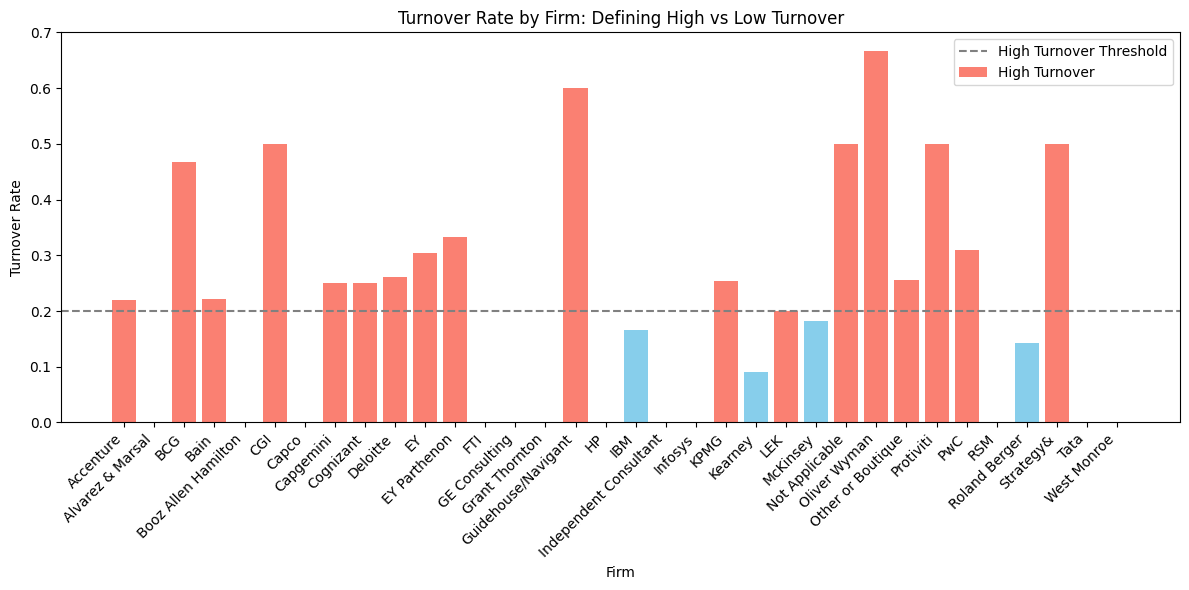

In [ ]:
# Encode 'accepted_offer' as follows: 'Yes' = 1, 'No' = 0, 'Thinking about it' and NaN = NaN // Let's not consider value else than no & yes for more simplicity
df['accepted_offer'] = df['accepted_offer'].apply(lambda x: 1 if x == 'Yes' else (0 if x == 'No' else np.nan))

# Calculate the turnover rate by firm, excluding "Thinking about it" and NaN values
turnover_rate_by_firm = df.groupby('current_firm')['accepted_offer'].mean()

# Convert to DataFrame for plotting
turnover_df = turnover_rate_by_firm.reset_index()
turnover_df.columns = ['Firm', 'Turnover Rate']

# Define threshold for high vs low turnover
threshold = 0.2
turnover_df['Turnover Category'] = turnover_df['Turnover Rate'].apply(lambda x: 'High' if x >= threshold else 'Low')


plt.figure(figsize=(12, 6))
colors = turnover_df['Turnover Category'].map({'High': 'salmon', 'Low': 'skyblue'})


plt.bar(turnover_df['Firm'], turnover_df['Turnover Rate'], color=colors)
plt.axhline(y=threshold, color='gray', linestyle='--', label=f'Threshold ({threshold*100}%)')

plt.title("Turnover Rate by Firm: Defining High vs Low Turnover")
plt.xlabel("Firm")
plt.ylabel("Turnover Rate")
plt.xticks(rotation=45, ha="right")
plt.legend(["High Turnover Threshold", "High Turnover", "Low Turnover"], loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
df["accepted_offer"].value_counts()

,count
accepted_offer,
0.0,631
1.0,261


In [ ]:
print("Checking for missing values:")
print(df[['current_compensation_usd', 'estimated_bonus_usd_2021', 'expected_total_compensation']].isnull().sum())


Checking for missing values:
current_compensation_usd       0
estimated_bonus_usd_2021       0
expected_total_compensation    0
dtype: int64


In [ ]:
print("\nChecking data types:")
print(df[['current_compensation_usd', 'estimated_bonus_usd_2021', 'expected_total_compensation']].dtypes)



Checking data types:
current_compensation_usd       float64
estimated_bonus_usd_2021       float64
expected_total_compensation    float64
dtype: object


In [ ]:
# Convert to numeric, forcing non-numeric values to NaN
df['current_compensation_usd'] = pd.to_numeric(df['current_compensation_usd'], errors='coerce')
df['estimated_bonus_usd_2021'] = pd.to_numeric(df['estimated_bonus_usd_2021'], errors='coerce')
df['expected_total_compensation'] = pd.to_numeric(df['expected_total_compensation'], errors='coerce')

# Recheck missing values
print("\nAfter conversion, missing values:")
print(df[['current_compensation_usd', 'estimated_bonus_usd_2021', 'expected_total_compensation']].isnull().sum())



After conversion, missing values:
current_compensation_usd       0
estimated_bonus_usd_2021       0
expected_total_compensation    0
dtype: int64



Recalculated Compensation Metrics:
                             High Turnover Mean  Low Turnover Mean
current_compensation_usd           93591.489256      107882.211066
estimated_bonus_usd_2021           14991.084396       89122.108609
expected_total_compensation       108582.573652      197004.319675


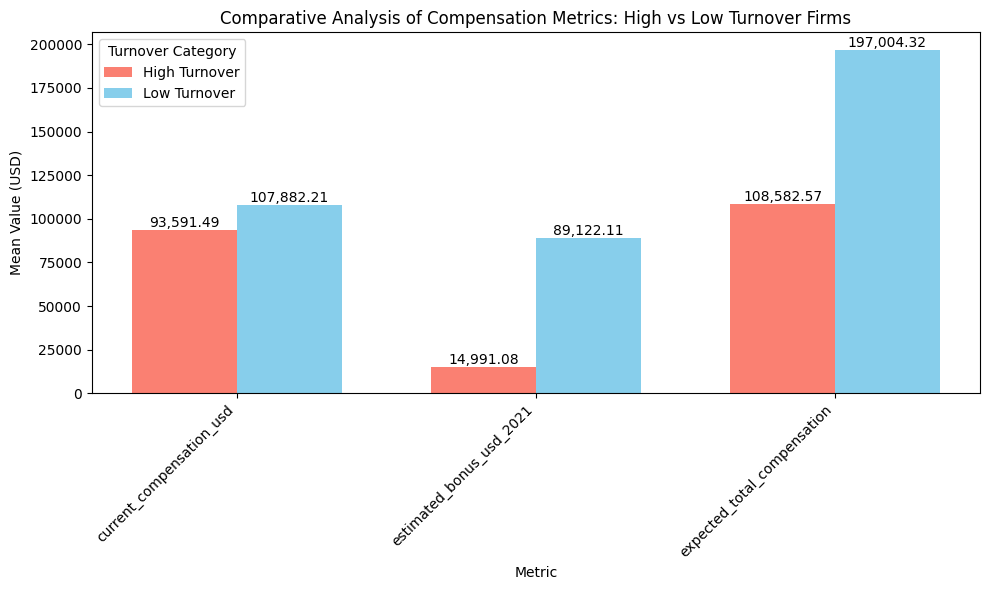

In [ ]:
 # Calculate turnover rate by firm
turnover_rate_by_firm = df.groupby('current_firm')['accepted_offer'].mean()

# Define threshold for high vs low turnover
threshold = 0.2
high_turnover_firms = turnover_rate_by_firm[turnover_rate_by_firm >= threshold].index
low_turnover_firms = turnover_rate_by_firm[turnover_rate_by_firm < threshold].index

# Ensure firms are categorized correctly after cleaning
high_turnover_data = df[df['current_firm'].isin(high_turnover_firms)]
low_turnover_data = df[df['current_firm'].isin(low_turnover_firms)]

compensation_metrics_values = {
    'current_compensation_usd': {
        'High Turnover Mean': high_turnover_data['current_compensation_usd'].mean(),
        'Low Turnover Mean': low_turnover_data['current_compensation_usd'].mean()
    },
    'estimated_bonus_usd_2021': {
        'High Turnover Mean': high_turnover_data['estimated_bonus_usd_2021'].mean(),
        'Low Turnover Mean': low_turnover_data['estimated_bonus_usd_2021'].mean()
    },
    'expected_total_compensation': {
        'High Turnover Mean': high_turnover_data['expected_total_compensation'].mean(),
        'Low Turnover Mean': low_turnover_data['expected_total_compensation'].mean()
    }
}

print("\nRecalculated Compensation Metrics:")
print(pd.DataFrame.from_dict(compensation_metrics_values, orient='index'))


# Plotting
compensation_df = pd.DataFrame.from_dict(compensation_metrics_values, orient='index').reset_index()
compensation_df.columns = ['Metric', 'High Turnover Mean', 'Low Turnover Mean']

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(compensation_df))

# Plot the bars
bars1 = ax.bar(index, compensation_df['High Turnover Mean'], bar_width, label='High Turnover', color='salmon')
bars2 = ax.bar(index + bar_width, compensation_df['Low Turnover Mean'], bar_width, label='Low Turnover', color='skyblue')

# Add value annotations on top of each bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.2f}',
        ha='center',
        va='bottom'
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.2f}',
        ha='center',
        va='bottom'
    )

# Formatting the plot
ax.set_xlabel('Metric')
ax.set_ylabel('Mean Value (USD)')
ax.set_title('Comparative Analysis of Compensation Metrics: High vs Low Turnover Firms')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(compensation_df['Metric'], rotation=45, ha="right")
ax.legend(title="Turnover Category")

plt.tight_layout()
plt.show()


In [ ]:
# Check the calculated metrics for both compensation and weekly hours
compensation_metrics_values = {
    'current_compensation_usd': {
        'High Turnover Mean': df['current_compensation_usd'].mean(),
        'Low Turnover Mean': df['current_compensation_usd'].mean()
    },
    'estimated_bonus_usd_2021': {
        'High Turnover Mean': df['estimated_bonus_usd_2021'].mean(),
        'Low Turnover Mean': df['estimated_bonus_usd_2021'].mean()
    },
    'expected_total_compensation': {
        'High Turnover Mean': df['expected_total_compensation'].mean(),
        'Low Turnover Mean': df['expected_total_compensation'].mean()
    }
}

# Weekly hours most frequent value
weekly_hours_values = {
    'High Turnover': df['weekly_hours'].mode().iloc[0] if not df['weekly_hours'].mode().empty else 'No Data',
    'Low Turnover': df['weekly_hours'].mode().iloc[0] if not df['weekly_hours'].mode().empty else 'No Data'
}

compensation_metrics_values, weekly_hours_values

({'current_compensation_usd': {'High Turnover Mean': 95114.78455947619,
   'Low Turnover Mean': 95114.78455947619},
  'estimated_bonus_usd_2021': {'High Turnover Mean': 34095.45942714285,
   'Low Turnover Mean': 34095.45942714285},
  'expected_total_compensation': {'High Turnover Mean': 129210.24398661905,
   'Low Turnover Mean': 129210.24398661905}},
 {'High Turnover': '40-49', 'Low Turnover': '40-49'})

In [ ]:
df

,timestamp,current_consulting_firm,current_firm,current_practice,current_title,current_country,current_compensation_usd,estimated_bonus_usd_2021,expected_total_compensation,weekly_hours,offer_received,offer_from_consulting_firm,highest_offer_firm,offer_practice,offered_title,offer_country,highest_offer_compensation_usd,highest_offer_bonus_usd,accepted_offer
0,9/29/2021 10:35:35,Yes,Other or Boutique,Commercial/non-federal Practice,Consultant/Associate,United States of America,147000.0,17000.0,164000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9/29/2021 10:35:44,Yes,McKinsey,Commercial/non-federal Practice,Senior Manager,Malaysia,142000.0,50000.0,192000.0,60-69,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9/29/2021 10:36:00,Yes,Deloitte,Commercial/non-federal Practice,Senior Consultant/Senior Associate,United States of America,150000.0,30000.0,180000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9/29/2021 10:36:16,Yes,Deloitte,Federal/government Practice,Senior Consultant/Senior Associate,United States of America,95000.0,10000.0,105000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9/29/2021 10:36:19,Yes,Kearney,Commercial/non-federal Practice,Consultant/Associate,United States of America,165000.0,32000.0,197000.0,70-79,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,10/19/2021 8:21:36,Yes,PwC,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United States of America,111000.0,8500.0,119500.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4196,10/19/2021 8:29:55,Yes,EY Parthenon,Commercial/non-federal Practice,Senior Manager,India,54000.0,10000.0,64000.0,50-59,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4197,10/19/2021 10:13:15,Yes,Accenture,Not Applicable or Don't Know,Senior Consultant/Senior Associate,United Kingdom,72000.0,0.0,72000.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4198,10/19/2021 10:30:46,No,NaN,NaN,NaN,United States of America,85800.0,0.0,85800.0,40-49,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def clean_hours(hours):
    hours_str = str(hours)

    if 'Not applicable' in hours_str or 'not currently working' in hours_str:
        return None  # or return 0 if you prefer to fill missing values with 0

    if '-' in hours_str:
        # Handle ranges like '50-59'
        min_hour, max_hour = hours_str.split('-')
        return (float(min_hour) + float(max_hour)) / 2
    elif '<' in hours_str:
        # Handle '<40' by converting it to 40
        return float(hours_str.replace('<', ''))
    elif '+' in hours_str:
        # Handle '80+' by converting it to 80
        return float(hours_str.replace('+', ''))
    else:
        # Convert any other valid numeric string to float
        return float(hours_str)

# Apply the cleaning function to the weekly_hours column in new_df, filling non-numeric values as NaN
df['weekly_hours'] = df['weekly_hours'].apply(clean_hours)

# Continue with the rest of your script
# Define turnover rate by firm
turnover_rate_by_firm = df.groupby('current_firm')['accepted_offer'].mean()

# Define high and low turnover firms (threshold: 50% of employees accepted offers)
high_turnover_firms = turnover_rate_by_firm[turnover_rate_by_firm >= 0.5].index
low_turnover_firms = turnover_rate_by_firm[turnover_rate_by_firm < 0.5].index

# Segment the dataset
df['turnover_category'] = np.where(df['current_firm'].isin(high_turnover_firms), 'High Turnover', 'Low Turnover')

# Comparative Analysis
# Metrics: current_compensation_usd, estimated_bonus_usd_2021, weekly_hours, highest_offer_compensation_usd
metrics = ['current_compensation_usd', 'estimated_bonus_usd_2021', 'weekly_hours', 'highest_offer_compensation_usd']

comparative_analysis = {}

for metric in metrics:
    # Separate data by turnover category
    high_turnover_data = df[df['turnover_category'] == 'High Turnover'][metric].dropna()
    low_turnover_data = df[df['turnover_category'] == 'Low Turnover'][metric].dropna()

    # Calculate mean and std deviation
    high_mean = high_turnover_data.mean()
    low_mean = low_turnover_data.mean()
    high_std = high_turnover_data.std()
    low_std = low_turnover_data.std()

    # Perform t-test
    t_stat, p_val = ttest_ind(high_turnover_data, low_turnover_data, equal_var=False)

    comparative_analysis[metric] = {
        'High Turnover Mean': high_mean,
        'Low Turnover Mean': low_mean,
        'High Turnover Std Dev': high_std,
        'Low Turnover Std Dev': low_std,
        't-statistic': t_stat,
        'p-value': p_val
    }

# Display comparative analysis results
comparative_df = pd.DataFrame(comparative_analysis).T
print("Comparative Analysis of High vs. Low Turnover Firms:")
print(comparative_df)


Comparative Analysis of High vs. Low Turnover Firms:
                                High Turnover Mean  Low Turnover Mean  \
current_compensation_usd             100956.586667       94898.421518   
estimated_bonus_usd_2021              23719.436667       34479.756566   
weekly_hours                             53.606667          51.662310   
highest_offer_compensation_usd       151808.097222      105903.770502   

                                High Turnover Std Dev  Low Turnover Std Dev  \
current_compensation_usd                 61093.195984          71824.481951   
estimated_bonus_usd_2021                 69957.527157         817618.637270   
weekly_hours                                 9.652796              9.081699   
highest_offer_compensation_usd          167679.061357         103263.173859   

                                t-statistic   p-value  
current_compensation_usd           1.184549  0.237903  
estimated_bonus_usd_2021          -0.765304  0.444155  
weekly_hours     